In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nalisha/job-salary-prediction-dataset/job_salary_prediction_dataset.csv


In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/job-salary-prediction-dataset/job_salary_prediction_dataset.csv')

In [4]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
df.isnull().sum() #Nothing is Null

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
df.shape


(250000, 10)

In [8]:
cols = df.columns
cols


Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [9]:
col = ['job_title','education_level','industry','company_size','location']
for i in  col:
    print(df[i].value_counts())
    print(" ")

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
 
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64
 
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
 
company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, 

In [10]:
df.duplicated().sum()

np.int64(0)

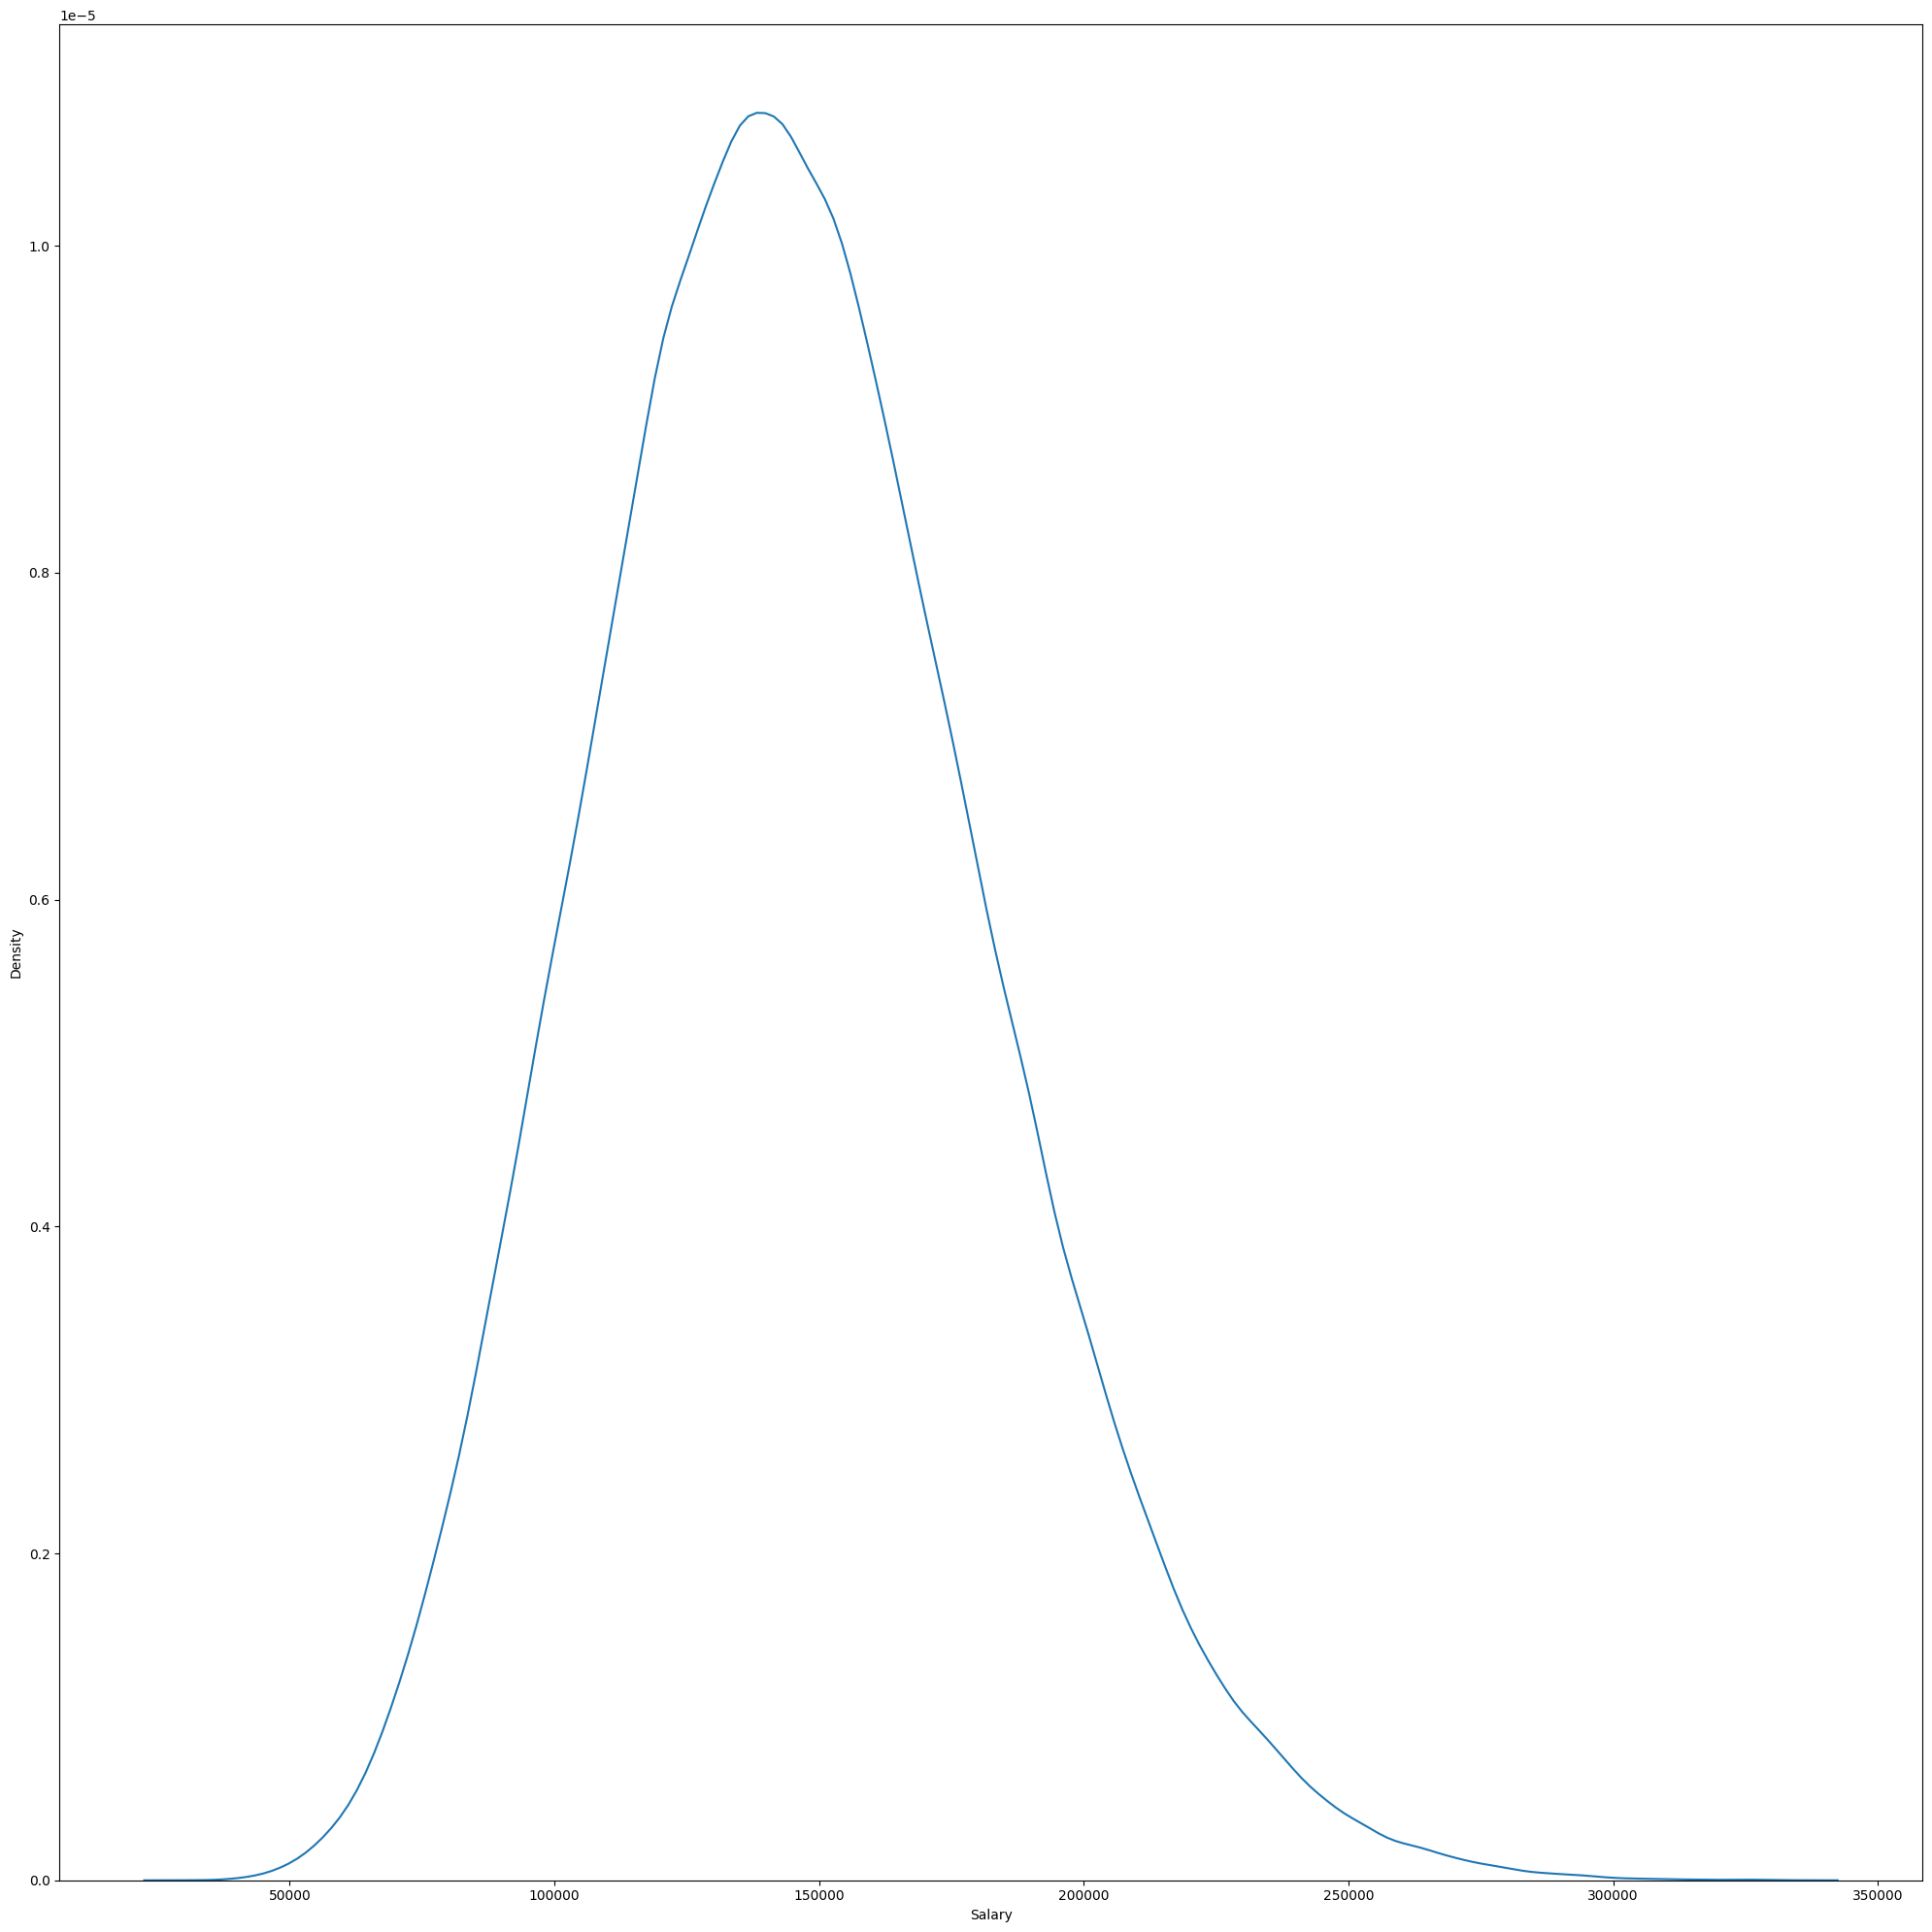

In [11]:
plt.figure(figsize=(20, 20))
sns.kdeplot(df['salary'])
plt.xlabel('Salary')
plt.tight_layout()
plt.show()

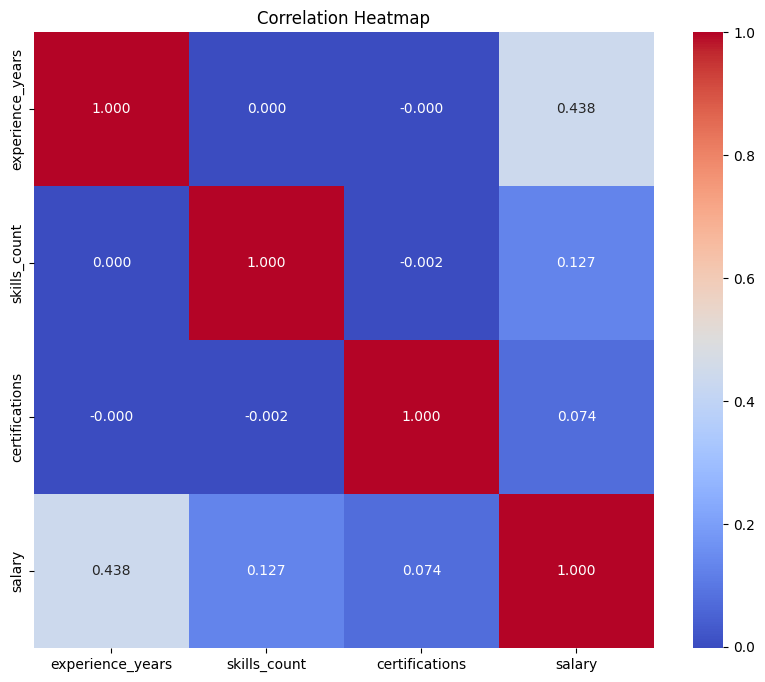

In [12]:

    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f")
    plt.title("Correlation Heatmap")
    plt.show()

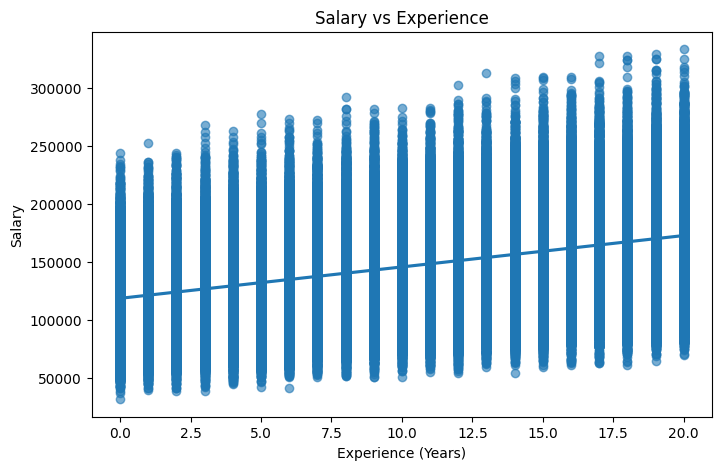

In [13]:
plt.figure(figsize=(8, 5))

sns.regplot(x=df['experience_years'],y=df['salary'],scatter_kws={'alpha':0.6})
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Salary vs Experience")

plt.show()

In [14]:
X = df.drop('salary', axis=1)
y = df['salary']
y = np.log(y) #Right Skewed

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.033661207510009186
MSE: 0.0019294280898752806
R2 Score: 0.9727757700916473


In [19]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.04062478768551435
MSE: 0.0027509814882562965
R2 Score: 0.9611836518277532
